# Walmart Weekly Sales Forecasting
### Data Preprocessing

In [ ]:
import pandas as pd

# Load the data
train = pd.read_csv("../data/train.csv")
stores = pd.read_csv("../data/stores.csv")
features = pd.read_csv("../data/features.csv")

# Create main table with left join (first with "stores", then with "features")
data = pd.merge(train, stores, on="Store", how="left")
data = pd.merge(data, features, on=["Store", "Date"], how="left")

# There are identical IsHoliday columns (IsHoldiay_x, IsHoliday_y), delete one of them and rename the other one
data = data.drop(columns="IsHoliday_y")
data = data.rename(columns={"IsHoliday_x": "IsHoliday"})

# There are blanks in the markdown columns. NaN values will be 0.
markdown_columns = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
data[markdown_columns] = data[markdown_columns].fillna(0)

### Feature Engineering

In [ ]:
# Date: string -> datetime
data['Date'] = pd.to_datetime(data['Date'])
# New features: Year, Month, Week of Year
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Week_of_Year'] = data['Date'].dt.isocalendar().week.astype(int)

# IsHoliday: True and False -> 1 and 0
data['IsHoliday'] = data['IsHoliday'].astype(int)

# Type: One-Hot Encoding
data = pd.get_dummies(data, columns=['Type'], drop_first=True, dtype=int)
# drop first: creates B and C columns. If they both 0, then it is A.

# New feature: Last Week Sales
data = data.sort_values(by=['Store', 'Dept', 'Date']).reset_index(drop=True)
data['Last_Week_Sales'] = data.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
data['Last_Week_Sales'] = data['Last_Week_Sales'].fillna(0)

### Data Splitting

In [ ]:
data = data.sort_values(by='Date').reset_index(drop=True)

# Data: 2010-02 | 2012-10
test_filter = (data['Year'] >= 2012) & (data['Month'] >= 9)

train_data = data[~test_filter].reset_index(drop=True)
val_data = data[test_filter].reset_index(drop=True)

y_train = train_data['Weekly_Sales']
X_train = train_data.drop(columns=['Weekly_Sales', 'Date'], errors='ignore')
y_val = val_data['Weekly_Sales']
X_val = val_data.drop(columns=['Weekly_Sales', 'Date'], errors='ignore')

### Model Import

In [ ]:
import xgboost as xgb

main_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1 # To use all of the cpu cores
)

### Feature Selection

In [ ]:
# RFE Selection
from sklearn.feature_selection import RFE
rfe_selector = RFE(estimator=main_model, n_features_to_select=10)
rfe_selector.fit(X_train, y_train)
rfe_selected_columns = X_train.columns[rfe_selector.support_].tolist()

# MRMR Selection
from mrmr import mrmr_regression
mrmr_selected_columns = mrmr_regression(X=X_train, y=y_train, K=10, show_progress=False) # Best 10

# LASSO Selection
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LassoCV
lasso_selector = SelectFromModel(LassoCV(cv=5), max_features=10)
lasso_selector.fit(X_train, y_train)
lasso_selected_columns = X_train.columns[lasso_selector.get_support()].tolist()

# SFS Selection
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression  # <--- Hız için hafif model
# Estimator olarak hafif bir model veriyoruz, böylece saniyeler içinde biter
fast_model = LinearRegression()
sfs_selector = SequentialFeatureSelector(fast_model, n_features_to_select=10, direction='forward', n_jobs=-1)
sfs_selector.fit(X_train, y_train)
sfs_selected_columns = X_train.columns[sfs_selector.get_support()].tolist()

### Model Training and Prediction

In [ ]:
# MRMR
main_model.fit(X_train[mrmr_selected_columns], y_train)
prediction_mrmr = main_model.predict(X_val[mrmr_selected_columns])

# RFE
main_model.fit(X_train[rfe_selected_columns], y_train)
prediction_rfe = main_model.predict(X_val[rfe_selected_columns])

# LASSO
main_model.fit(X_train[lasso_selected_columns], y_train)
prediction_lasso = main_model.predict(X_val[lasso_selected_columns])

# SFS
main_model.fit(X_train[sfs_selected_columns], y_train)
prediction_sfs = main_model.predict(X_val[sfs_selected_columns])

# All Features
main_model.fit(X_train, y_train)
prediction_all = main_model.predict(X_val)

### Model Validation

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

def wmape(real, prediction):
    return (np.abs(real - prediction).sum() / real.sum()) * 100

results = {
    "MRMR Selection": {
        "RMSE ($)": np.sqrt(mean_squared_error(y_val, prediction_mrmr)),
        "WMAPE (%)": wmape(y_val.values, prediction_mrmr)
    },
    "RFE Selection": {
        "RMSE ($)": np.sqrt(mean_squared_error(y_val, prediction_rfe)),
        "WMAPE (%)": wmape(y_val.values, prediction_rfe)
    },
    "LASSO Selection": {
        "RMSE ($)": np.sqrt(mean_squared_error(y_val, prediction_lasso)),
        "WMAPE (%)": wmape(y_val.values, prediction_lasso)
    },
    "SFS Selection": {
        "RMSE ($)": np.sqrt(mean_squared_error(y_val, prediction_sfs)),
        "WMAPE (%)": wmape(y_val.values, prediction_sfs)
    },
    "All Features": {
        "RMSE ($)": np.sqrt(mean_squared_error(y_val, prediction_all)),
        "WMAPE (%)": wmape(y_val.values, prediction_all)
    }
}

### Validation Results

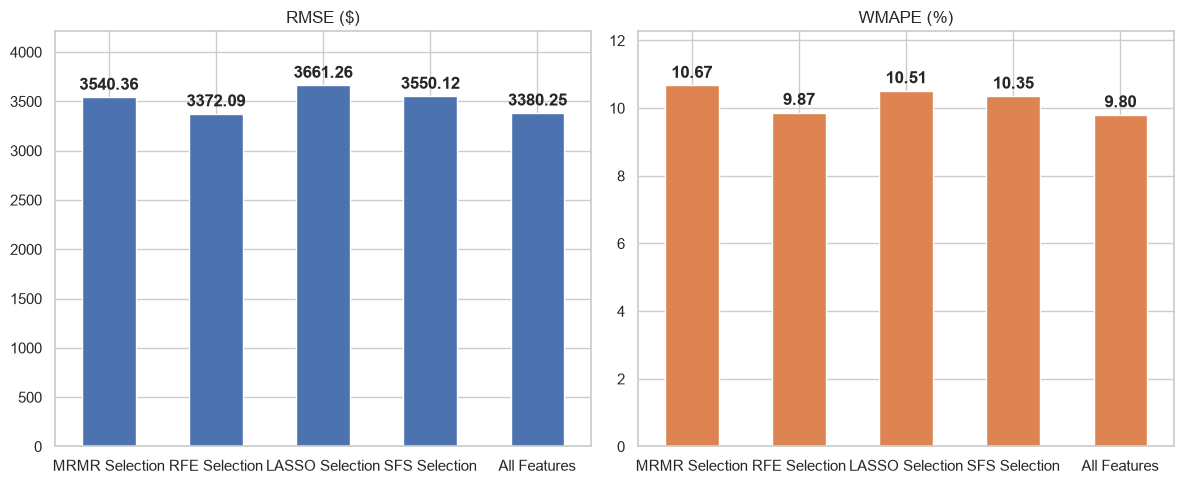

,RMSE ($),WMAPE (%)
MRMR Selection,3540.36,10.67
RFE Selection,3372.09,9.87
LASSO Selection,3661.26,10.51
SFS Selection,3550.12,10.35
All Features,3380.25,9.80


In [ ]:
import matplotlib.pyplot as plt

def plot_results(df):
    # 1. Automatically plot all columns as subplots side-by-side
    ax = df.plot(kind='bar', subplots=True, layout=(1, len(df.columns)), figsize=(6 * len(df.columns), 5), rot=0, legend=False)
    
    # 2. Automatically push values on top of each bar and add top margin
    for i in range(len(df.columns)):
        ax[0, i].bar_label(ax[0, i].containers[0], fmt='%.2f', padding=3, fontweight='bold')
        ax[0, i].margins(y=0.15) # Automatically adds space at the top for labels
        
    plt.tight_layout()
    plt.show()

report_df = pd.DataFrame(results).T.round(2)
plot_results(report_df)
report_df